<br>
<font>
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=150 height=150> <br>
<font color=0F5298 size=7>
Artificial Intelligence <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Spring 2025<br>
<font color=3C99D size=5>
Practical Assignment 1 - Search <br>
<font color=696880 size=4>
Amir Homayoon sharifi zade

____________

In [ ]:
#insert your information
NAME = 'Mohammad Ali Meschi'
STUDENT_NUMBER = '402106491'

# Libraries

In [73]:
import random
import heapq
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque
import time
from itertools import combinations
from collections import Counter

# **Uninformed Search**

In this part you are going to implement the famous algorithms of graph search on some random graph.
At first you will implement DFS, after that BFS will be implemented and finally you'll implement some heuristic and preform A*.
Here are some helper functions to generate and plot the graph. Do not touch the code in the below cells and only complete the parts with a TODO hashtag.

In [17]:
# Create a random graph with blocked edges (None means blocked)
def generate_random_graph(n, edge_probability=0.1, max_weight=10):
    graph = {i: {} for i in range(n)}
    for node in range(n):
        for neighbor in range(node + 1, n):
            if random.random() < edge_probability:  # Edge exists with given probability
                weight = random.randint(1, max_weight)
                graph[node][neighbor] = weight
                graph[neighbor][node] = weight
    return graph

In [ ]:
def plot_graph(graph, path=None, explored=None):
    # Create a fixed layout using networkx's spring layout (force-directed)
    G = nx.Graph(graph)

    # Fixed layout (positions determined from the graph)
    pos = nx.spring_layout(G, seed=42)  # Ensures the same layout every time

    # Draw edges
    fig, ax = plt.subplots(figsize=(8, 8))
    nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color='gray', width=1.5)  # Draw all edges in gray

    # Draw nodes (default color for non-explored and non-path nodes)
    nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightgreen', label="Nodes")

    # Highlight the explored nodes
    if explored:
        nx.draw_networkx_nodes(G, pos, nodelist=explored, node_size=300, node_color='blue', label="Explored")

    # Highlight the path nodes
    if path:
        nx.draw_networkx_nodes(G, pos, nodelist=path, node_size=300, node_color='red', label="Path")

    # Add labels for the nodes
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', font_color='black')

    # Add the legend
    ax.legend()

    ax.set_title("Graph Visualization")
    plt.axis('off')  # Turn off the axis for a cleaner visualization
    plt.show()


# DFS

In [ ]:
def dfs(graph, start, goal):
    stack = [(start, [start])]
    explored = set()

    while stack:
        node, path = stack.pop()
        if node == goal:
            return path, list(explored)

        if node not in explored:
            explored.add(node)
            for neighbor in graph.get(node, []):
                if neighbor not in explored:
                    stack.append((neighbor, path + [neighbor]))

    return None, list(explored)  # Return None if no path is found

# BFS

In [ ]:
def bfs(graph, start, goal):
    queue = deque([(start, [start])])
    explored = set()

    while queue:
        node, path = queue.popleft()
        if node == goal:
            return path, list(explored)

        if node not in explored:
            explored.add(node)
            for neighbor in graph.get(node, []):
                if neighbor not in explored:
                    queue.append((neighbor, path + [neighbor]))

    return None, list(explored)  # Return None if no path is found

**So far, we have explored two uninformed search methods: DFS, BFS. Briefly explain the advantages and disadvantages of each method in the context of the Maze Problem and compare their performance based on your observations (consider both time and memory).**

هر دو این روش‌ها بدون در نظر گرفتن اطلاعاتی در مورد هدف نهایی و با روش‌های از پیش مشخص به دنبال هدف نهایی می‌گردند.


 با توجه به اینکه محیط ما یک گراف حالت است، هیچ خطری برای افتادن در یک حلقه بی‌نهایت در جستجوی DFS وجود ندارد. با این حال، به دلیل وزن‌دار بودن گراف و عدم توجه هر دو روش به وزن یال‌ها، هیچ تضمینی برای یافتن مسیر بهینه با هیچ یک از این روش‌ها وجود ندارد. یک مزیت جستجوی DFS استفاده بهینه از فضاست، زیرا فقط یک مسیر را حفظ می‌کند و بنابراین پیچیدگی فضایی آن O(b.d) است، که در آن b عامل انشعاب و d عمق مسیر بهینه است. در مقابل، جستجوی BFS برخلاف DFS به صورت نمایی رشد می‌کند، زیرا تمام حالت‌های هر سطح را حفظ می‌کند (O(b^d)).

از نظر پیچیدگی زمانی، هر دو میانگین پیچیدگی زمانی O(b^d) را دارند. یک مزیت جستجوی BFS این است که اگر وزن یال‌ها یکنواخت باشد، می‌توان با اطمینان گفت که مسیر بهینه را ارائه می‌دهد.



# A star


In [15]:
# Define heuristic functions
# A* Search (using simple heuristics: Manhattan distance or random)
def manhattan_distance(a, b, pos):
    xa, ya = pos[a]
    xb, yb = pos[b]
    return abs(xa - xb) + abs(ya - yb)

# Random heuristic
def random_heuristic(a, b, pos):
    return random.randint(1, 10)  # Random heuristic for demonstration

def a_star(graph, start, goal, heuristic, pos):
    # initialize the set of priority_queue in format (g , f , node , path) & explored nodes
    priority_queue = {(0, heuristic(start, goal, pos), start, (start,))}
    explored = []

    # A* loop
    while priority_queue:
        # pop the node that has the minimum f in priority_queue
        node = min(priority_queue, key=lambda x: x[1])
        priority_queue.remove(node)
        g = node[0]
        current_node = node[2]
        path = node[3]

        if current_node not in explored:
          explored.append(current_node)
          if current_node == goal:
              return list(path), explored
          for child in graph[current_node]:
              if child not in explored:
                  new_g = g + graph[current_node][child]
                  new_f = new_g + heuristic(child, goal, pos)
                  priority_queue.add((new_g, new_f, child, path + (child,)))

    # if you reach this line , it means the goal doesn't find and all nodes are exploded
    return None, explored


# Results

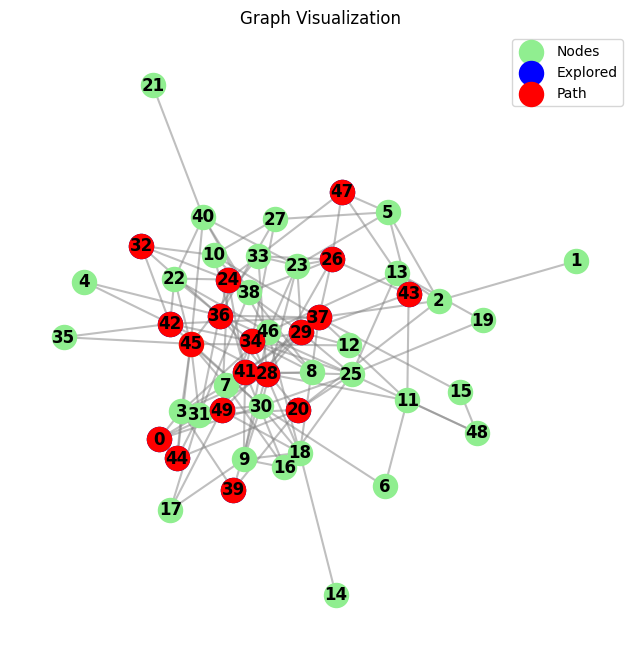

DFS Path: [0, 49, 41, 34, 42, 37, 36, 32, 24, 47, 26, 43, 29, 28, 39, 20, 44, 45]


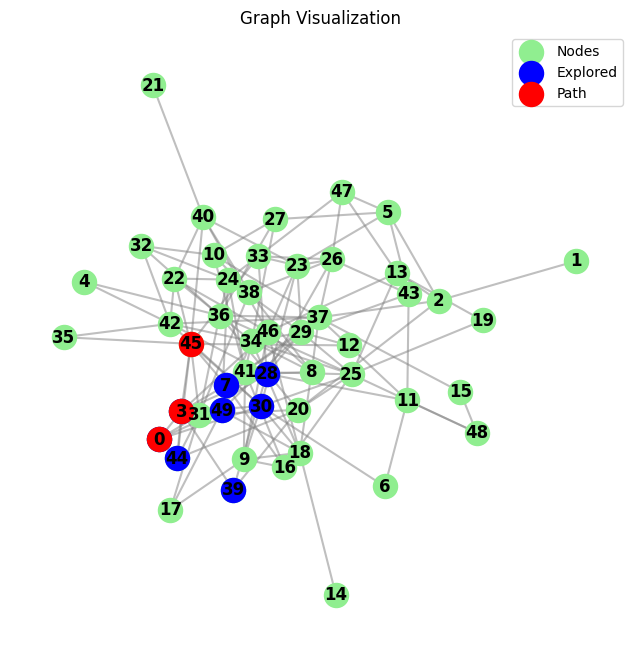

BFS Path: [0, 3, 45]


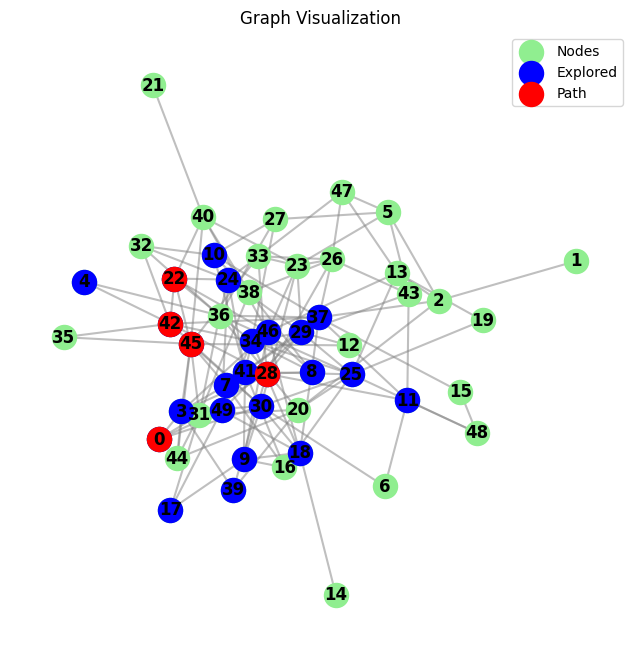

A* Path with Random Heuristic: [0, 28, 42, 22, 45]


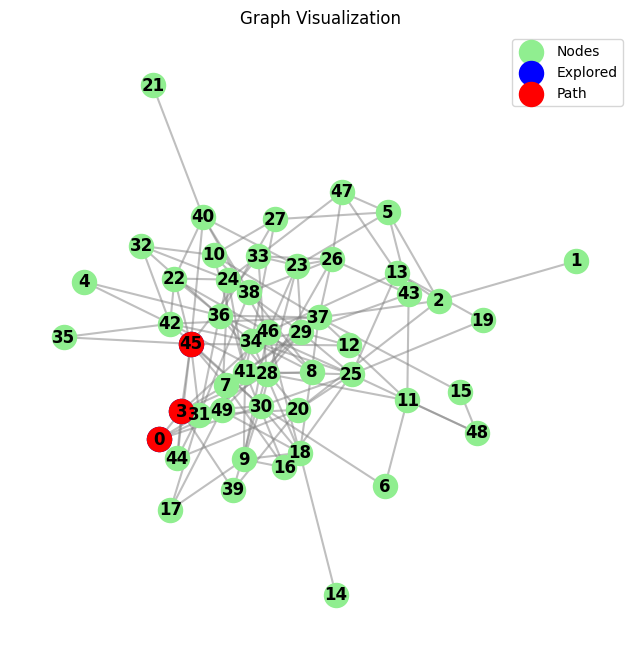

A* Path with Manhattan Distance Heuristic: [0, 3, 45]


In [16]:
# Parameters
num_nodes = 50  # Number of nodes in the graph
start_node = 0  # Starting node
goal_node = 45   # Goal node

# Generate random graph
random_graph = generate_random_graph(num_nodes)

# # Get random node positions for Manhattan distance calculation
positions = {i: (random.randint(0, 100), random.randint(0, 100)) for i in range(num_nodes)}

# Run DFS
path_dfs, explored_dfs = dfs(random_graph, start_node, goal_node)
plot_graph(random_graph, path=path_dfs, explored=explored_dfs)
print(f"DFS Path: {path_dfs}")

# Run BFS
path_bfs, explored_bfs = bfs(random_graph, start_node, goal_node)
plot_graph(random_graph, path=path_bfs, explored=explored_bfs)
print(f"BFS Path: {path_bfs}")

# Run A* with Random Heuristic in same manner as above
path_a_star_random, explored_a_star_random = a_star(random_graph, start_node, goal_node, random_heuristic,positions)
plot_graph(random_graph, path=path_a_star_random, explored=explored_a_star_random)
print(f"A* Path with Random Heuristic: {path_a_star_random}")

# Run A* with Manhattan Distance Heuristic
path_a_star_manhattan, explored_a_star_manhattan = a_star(random_graph, start_node, goal_node, manhattan_distance ,positions)
plot_graph(random_graph, path=path_a_star_manhattan, explored=explored_a_star_manhattan)
print(f"A* Path with Manhattan Distance Heuristic: {path_a_star_manhattan}")


**Explain your heuristic and observation's result. Also, compare the A\* method with Uninformed search in the context of the problem.**

برای پیاده‌سازی جستجوی A*، دو نوع تابع هیورستیک تعریف کردیم. یکی از آن‌ها به هر حالت یک عدد تصادفی اختصاص می‌داد و دیگری فاصله منهتن را بر اساس مختصات محاسبه می‌کرد. تابع هیورستیک دوم بهتر و معتبرتر از تابع اول است، زیرا admissible بوده و گراف را یکنواخت (monotonic) می‌کند که برای معتبر بودن جستجوی A* ضروری است.

به طور کلی، این جستجوی آگاهانه (informed search)، علاوه بر در نظر گرفتن مسیری که طی کرده است، فاصله تخمینی تا هدف را نیز برای حرکت بعدی خود در نظر می‌گیرد. بنابراین می‌توان گفت که این روش به صورت کورکورانه به دنبال هدف نمی‌گردد. در نتیجه، زمان رسیدن به هدف در این روش کمتر از جستجوهای ناآگاهانه (uninformed searches) است، زیرا گره‌های بی‌فایده کمتری را باز می‌کند و به شیوه‌ای هدف‌مندتر به جستجوی هدف می‌پردازد.

این روش همچنین وزن یال‌ها را نیز در نظر می‌گیرد، برخلاف جستجوهای ناآگاهانه که فقط تعداد یال‌ها را مد نظر قرار می‌دادند. می‌توان گفت که راه‌حل مسیریابی A* به طور قابل توجهی معتبرتر از دو الگوریتم قبلی است.

# **Weigted Graph**

In this part we are going to explore a situation in which every vertice has some cost and we want to minimize the cost as well. So one can say that the part before was a special kind of Weighted Graph with weights equal to 1 in every vertice.
Again the two cells below are helper functions that should not be modified.

In [18]:
# Create a random graph with weights on edges
def generate_weighted_graph(n, edge_probability=0.1, max_weight=10):
    graph = {i: {} for i in range(n)}

    for node in range(n):
        for neighbor in range(node + 1, n):
            if random.random() < edge_probability:  # Edge exists with given probability
                weight = random.randint(1, max_weight)
                graph[node][neighbor] = weight
                graph[neighbor][node] = weight  # Undirected graph
    return graph


In [19]:
def plot_graph(graph, path=None, explored=None):
    # Create a fixed layout using networkx's spring layout (force-directed)
    G = nx.Graph(graph)

    # Fixed layout (positions determined from the graph)
    pos = nx.spring_layout(G, seed=42)  # Ensures the same layout every time

    # Draw edges
    fig, ax = plt.subplots(figsize=(8, 8))
    nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color='gray', width=1.5)  # Draw all edges in gray

    # Draw nodes (default color for non-explored and non-path nodes)
    nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightgreen', label="Nodes")

    # Highlight the explored nodes
    if explored:
        nx.draw_networkx_nodes(G, pos, nodelist=explored, node_size=300, node_color='blue', label="Explored")

    # Highlight the path nodes
    if path:
        nx.draw_networkx_nodes(G, pos, nodelist=path, node_size=300, node_color='red', label="Path")

    # Add labels for the nodes
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', font_color='black')

    # Display edge weights (weights on the edges)
    edge_labels = {(u, v): graph[u][v] for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color='blue')

    # Add the legend
    ax.legend()

    ax.set_title("Graph Visualization with Weights")
    plt.axis('off')  # Turn off the axis for a cleaner visualization
    plt.show()


# DFS With Cost

In [36]:
# Depth-First Search (DFS) with weight sum
def dfs_weighted(graph, start, goal):
    stack = [(start, [start], 0)]
    explored = []

    while stack:
        current_node, path, weight_sum = stack.pop()
        explored.append(current_node)

        if current_node == goal:
            return path, weight_sum, explored

        # Iterate neighbors in reversed order to maintain the correct DFS order
        for neighbor in reversed(list(graph[current_node].keys())):
            if neighbor not in path:
                new_path = path + [neighbor]
                new_weight = weight_sum + graph[current_node][neighbor]
                stack.append((neighbor, new_path, new_weight))

    return None


# BFS With Cost

In [37]:
# Breadth-First Search (BFS) with weight sum
def bfs_weighted(graph, start, goal):
    queue = deque([(start, [start], 0)])
    explored = []

    while queue:
        node, path, weight_sum = queue.popleft()
        if node == goal:
            return path, weight_sum, explored

        if node not in explored:
            explored.append(node)
            for neighbor in graph.get(node, []):
                if neighbor not in explored:
                    queue.append((neighbor, path + [neighbor], weight_sum + graph[node][neighbor]))

    return None, list(explored)  # Return None if no path is found


# Dijkstra (UCS)

In [38]:
# Dijkstra's Algorithm
def dijkstra(graph, start, goal):
    # Priority queue to hold nodes to be explored, based on their tentative distance
    # Distance to start node is 0, all others are infinity initially
    distances = {node: float('inf') for node in graph}
    distances[start] = 0

    # Dictionary to store the predecessor of each node for path reconstruction
    predecessors = {node: None for node in graph}

    # Priority queue for exploration, initialized with the start node
    priority_queue = [(0, start)]

    # List to store the nodes that have been explored
    explored = []

    while priority_queue:
        # Get the node with the smallest distance
        current_distance, current_node = heapq.heappop(priority_queue)
        explored.append(current_node)

        # If we have reached the goal, stop the search
        if current_node == goal:
            break

        # Explore each neighbor of the current node
        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight

            # If a shorter path to the neighbor is found, update the distance and priority queue
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                predecessors[neighbor] = current_node
                heapq.heappush(priority_queue, (distance, neighbor))

    # Reconstruct the path from start to goal
    path = []
    current_node = goal
    while current_node is not None:
        path.insert(0, current_node)
        current_node = predecessors[current_node]

    # Calculate the total weight of the path
    weight_sum = distances[goal] if distances[goal] != float('inf') else None

    return path, weight_sum, explored


# Results

DFS Path: [0, 5, 3, 4, 27, 7, 2, 8, 14, 16, 18, 32, 23, 10, 11, 37, 1, 6, 25, 21, 26, 44, 15, 12, 13, 43, 17, 35, 19, 20, 22, 36, 41, 28, 33, 45]
DFS Weight Sum: 177
BFS Path: [0, 11, 45]
BFS Weight Sum: 14
Dijkstra Path: [0, 5, 36, 45]
Dijkstra Weight Sum: 6


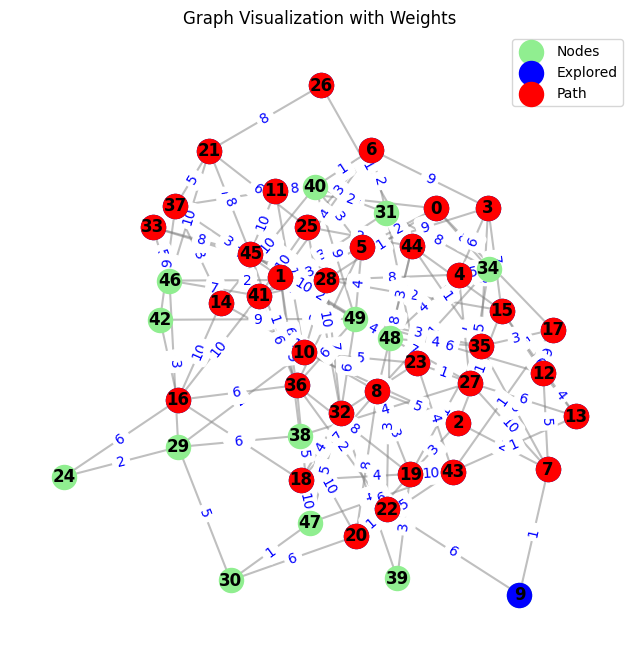

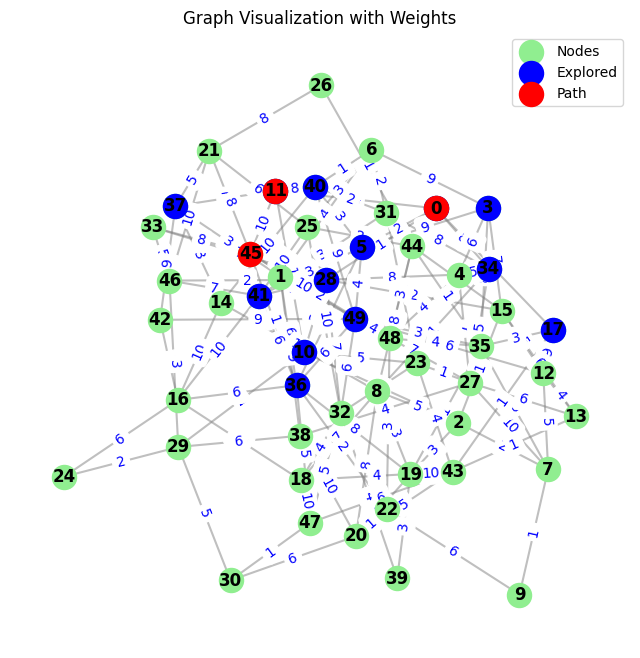

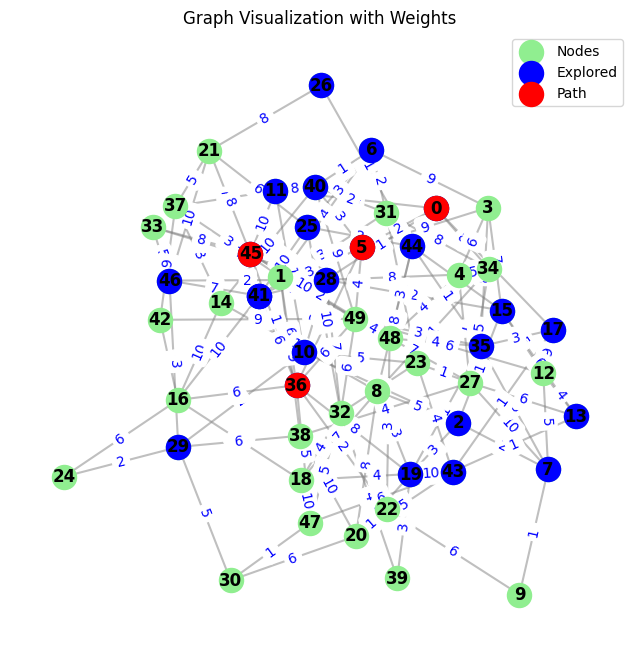

In [86]:
# Parameters
num_nodes = 50  # Number of nodes in the graph
start_node = 0  # Starting node
goal_node = 45   # Goal node

# Generate random weighted graph
weighted_graph = generate_weighted_graph(num_nodes)

# Run DFS
path_dfs, weight_dfs, explored_dfs = dfs_weighted(weighted_graph, start_node, goal_node)
print(f"DFS Path: {path_dfs}")
print(f"DFS Weight Sum: {weight_dfs}")

# Run BFS
path_bfs, weight_bfs, explored_bfs = bfs_weighted(weighted_graph, start_node, goal_node)
print(f"BFS Path: {path_bfs}")
print(f"BFS Weight Sum: {weight_bfs}")

# Run Dijkstra
path_dijkstra, weight_dijkstra, explored_dijkstra = dijkstra(weighted_graph, start_node, goal_node)
print(f"Dijkstra Path: {path_dijkstra}")
print(f"Dijkstra Weight Sum: {weight_dijkstra}")

# Visualize the results
plot_graph(weighted_graph, path=path_dfs, explored=explored_dfs)
plot_graph(weighted_graph, path=path_bfs, explored=explored_bfs)
plot_graph(weighted_graph, path=path_dijkstra, explored=explored_dijkstra)


**What are the key diffrences between dijkstra, bfs and dfs? Which one of them has acted better in our problem and why? What happens when graph is directed?**

تفاوت کلیدی بین الگوریتم دایکسترا و دو جستجوی قبلی، در نظر گرفتن وزن یال‌ها است. دایکسترا در هر مرحله طول کمینه مسیر از گره شروع به هر حالت را به‌روزرسانی می‌کند، به گونه‌ای که گراف از گره شروع بلند می‌شود و گره‌ها به ترتیب افزایش فاصله‌شان از گره شروع پیمایش می‌شوند. با این حال، در دو جستجوی قبلی، فقط وجود مسیر بین دو گره بررسی می‌شد و وزن یال‌ها در نظر گرفته نمی‌شد. به راحتی می‌توان نتیجه گرفت که دایکسترا نتیجه‌ای به مراتب معتبرتر و واقع‌بینانه‌تر برمی‌گرداند.

اگر یال‌های ما جهت‌دار باشند، در الگوریتم دایکسترا دیگر نمی‌توانیم همه فرزندان هر گره را در هر مرحله به‌روزرسانی کنیم؛ فقط فرزندانی که جهت یال آن‌ها از والد به فرزند باشد قابل به‌روزرسانی هستند. علاوه بر این، در BFS و DFS، فقط می‌توانیم مسیرهایی را پیمایش کنیم که در جهت صحیح باشند.

# **Local Search**

# Problem definition
In this part, you should implement **Hill-Climbing** and **Genentic** algorithms. Afterwards you will test them on a formal np problem (Subset Sum)

Suppose we have a limit for our back pack that we show with *target_sum* and random number of materials with some rand weights which are present in *nums*. To do that we will implement 3 algorithms. First, you should implement  **Hill-Climbing**, and then you should implement the **Genetic Algorithm**. At last, you should find the actual answer using **Naive Search (brute force)**.

In [43]:
# Sample input for Subset Sum Problem
target_sum = 60
nums = [random.randint(1, 10) for _ in range(15)]  # Random list of 15 integers between 1 and 10

print(f"Numbers: {nums}")
print(f"Target Sum: {target_sum}")


Numbers: [4, 3, 6, 6, 10, 2, 5, 8, 10, 2, 1, 10, 8, 5, 8]
Target Sum: 60


# Hill Climbing

In order to implement hill climbing, you must at first define the neighbors in your model. We suggest that every addition or omition of your current bag should be a neighbor yet you can implement it how you want.

In [70]:
def hill_climbing(nums, target_sum):
    # Random initial solution (subset of nums)
    current_solution = random.sample(nums, random.randint(1, len(nums)))
    current_sum = sum(current_solution)

    # Hill climbing loop
    while True:
        # Generate neighbors by adding or removing one element
        neighbors = []
        for num in nums:
            if num not in current_solution:
                # Add a new element
                neighbor = current_solution.copy()
                neighbor.append(num)
                neighbors.append(neighbor)
            else:
                # Remove an existing element
                neighbor = current_solution.copy()
                neighbor.remove(num)
                neighbors.append(neighbor)

        # Evaluate neighbors by calculating the sum
        best_neighbor = None
        best_neighbor_sum = current_sum
        for neighbor in neighbors:
            neighbor_sum = sum(neighbor)
            # Check if the neighbor is closer to the target sum
            if abs(neighbor_sum - target_sum) < abs(best_neighbor_sum - target_sum):
                best_neighbor = neighbor
                best_neighbor_sum = neighbor_sum

        # If no improvement, stop
        if best_neighbor_sum == current_sum:
            break

        # Update current solution
        current_solution = best_neighbor
        current_sum = best_neighbor_sum

    return current_solution



# Genetic Algorithm
As you have learned, in order to implement GA, you need to define mutation function and crossover functions(single pointed one would be enough).

Then, in main GA body, a population of random solutions (subsets) is created. These solutions evolve over a number of generations through selection, crossover, and mutation.
The algorithm aims to evolve the population towards finding a subset whose sum is as close as possible to the target sum. After a set number of generations, the algorithm returns the best solution found.

In [77]:
def tournament_selection(population, target_sum, tournament_size=5):
    tournament = random.sample(population, tournament_size)
    tournament.sort(key=lambda x: abs(target_sum - sum(x)))
    return tournament[0]  # Best solution in the tournament

def crossover(parent1, parent2):
    # Single-point crossover
    if len(parent1) == 0 or len(parent2) == 0:
        return parent1, parent2  # If one parent is empty, return parents as children

    # Randomly choose a crossover point
    crossover_point = random.randint(1, min(len(parent1), len(parent2)) - 1)

    # Create children by swapping parts of the parents
    child1 = parent1[:crossover_point] + parent2[crossover_point:]
    child2 = parent2[:crossover_point] + parent1[crossover_point:]

    return child1, child2

def mutate(solution, nums, mutation_rate=0.1):
    # Mutate the solution
    if random.random() < mutation_rate:  # Check if mutation should happen
        if random.random() < 0.5:  # 50% chance to add or remove
            # Add a random number from nums that isn't in the solution
            available_numbers = [num for num in nums if num not in solution]
            if available_numbers:
                solution.append(random.choice(available_numbers))
        else:
            # Remove a random number from the solution
            if solution:
                solution.remove(random.choice(solution))

    return solution




In [83]:
def fitness(solution, target_sum):
    # Fitness function: how close the sum of the solution is to the target_sum
    return abs(sum(solution) - target_sum)

def tournament_selection(population, fitness_scores, tournament_size=3):
    # Tournament selection: select the best individual from a random subset of the population
    selected = random.sample(list(zip(population, fitness_scores)), tournament_size)
    # Return the solution with the best (lowest) fitness score
    return min(selected, key=lambda x: x[1])[0]

def genetic_algorithm(nums, target_sum, population_size=50, generations=100, mutation_rate=0.1):
    # Random initial population
    population = [random.sample(nums, random.randint(1, len(nums))) for _ in range(population_size)]

    for generation in range(generations):
        # Evaluate fitness of each solution in the population
        fitness_scores = [fitness(solution, target_sum) for solution in population]

        # Check if we have found a perfect solution
        best_solution = population[fitness_scores.index(min(fitness_scores))]
        if sum(best_solution) == target_sum:
            return best_solution

        # Create the next generation
        new_population = []
        while len(new_population) < population_size:
            # Select parents using tournament selection
            parent1 = tournament_selection(population, fitness_scores)
            parent2 = tournament_selection(population, fitness_scores)

            # Perform crossover to create children
            child1, child2 = crossover(parent1, parent2)

            # Mutate children
            child1 = mutate(child1, nums, mutation_rate)
            child2 = mutate(child2, nums, mutation_rate)

            # Add children to the new population
            new_population.append(child1)
            new_population.append(child2)

        # Replace the old population with the new population
        population = new_population[:population_size]

    # Return the best solution after all generations
    best_solution = min(population, key=lambda x: fitness(x, target_sum))
    return best_solution

# Brute Force

In [68]:
def brute_force(nums, target_sum):
    # initializations
    n = len(nums)
    best_subset = None
    best_objective_function = float('inf')

    # itarate mask from 1 to 2^n (each biary shape of mask is shown one subset)
    for mask in range(1, 1 << n):
        subset = []
        for i in range(n):
            # Check if the i-th bit in mask is set
            if mask & (1 << i):
                subset.append(nums[i])
        current_sum = sum(subset)
        objective_function = abs(target_sum - current_sum)

        # if found the answer
        if objective_function == 0:
            return subset

        # replace the best if this subset is better
        if objective_function < best_objective_function:
            best_objective_function = objective_function
            best_subset = subset

    return best_subset

# Comparison

Run the 3 algorithms 10 times and watch the result. Hill climbing and Genetic Algorithm results should be close to actual answers(brute force results).


In [85]:
# Running the algorithms multiple times with different random setups
def run_multiple_trials(num_trials=10):
    hill_climbing_times = []
    ga_times = []
    brute_force_times = []

    hill_climbing_solutions = []
    ga_solutions = []
    brute_force_solutions = []

    for i in range(num_trials):
        # Generate random setup for each trial
        target_sum = random.randint(50, 100)  # Random target sum between 10 and 50
        nums = [random.randint(1, 10) for _ in range(random.randint(10, 30))]  # Random list size between 10 and 20
        hill_climb_sum = 0
        genetic_sum = 0
        brute_force_sum = 0
        # Print the current trial setup
        print(f"Trial {i + 1}: Target Sum = {target_sum}, Numbers = {nums}")

        # Hill Climbing
        start_time = time.time()
        hill_climb_result = hill_climbing(nums, target_sum)
        hill_climb_time = time.time() - start_time
        hill_climbing_times.append(hill_climb_time)
        hill_climbing_solutions.append(hill_climb_result)
        hill_climb_sum = sum(hill_climb_result)

        # Genetic Algorithm
        start_time = time.time()
        ga_result = genetic_algorithm(nums, target_sum)
        ga_time = time.time() - start_time
        ga_times.append(ga_time)
        ga_solutions.append(ga_result)
        genetic_sum = sum(ga_result)

        # Brute Force
        start_time = time.time()
        brute_force_result = brute_force(nums, target_sum)
        brute_force_time = time.time() - start_time
        brute_force_times.append(brute_force_time)
        brute_force_solutions.append(brute_force_result)
        brute_force_sum = sum(brute_force_result) if brute_force_result else 0

        # Print each trial result
        print(f"Hill Climbing Result: {hill_climb_result}, final sum: {hill_climb_sum}, Time Taken: {hill_climb_time:.4f} seconds")
        print(f"Genetic Algorithm Result: {ga_result}, final sum: {genetic_sum}, Time Taken: {ga_time:.4f} seconds")
        print(f"Brute Force Result: {brute_force_result}, final sum: {brute_force_sum}, Time Taken: {brute_force_time:.4f} seconds\n")

    # Calculate average times
    avg_hill_climbing_time = sum(hill_climbing_times) / num_trials
    avg_ga_time = sum(ga_times) / num_trials
    avg_brute_force_time = sum(brute_force_times) / num_trials

    print("\nAverage Times over 10 Trials:")
    print(f"Hill Climbing Average Time: {avg_hill_climbing_time:.4f} seconds")
    print(f"Genetic Algorithm Average Time: {avg_ga_time:.4f} seconds")
    print(f"Brute Force Average Time: {avg_brute_force_time:.4f} seconds")

# Run the comparison with 10 trials
run_multiple_trials(num_trials=10)


Trial 1: Target Sum = 84, Numbers = [10, 2, 3, 2, 9, 10, 3, 8, 6, 6, 1, 6, 8, 5, 9, 1, 4, 3, 1, 8, 6, 9]
Hill Climbing Result: [5, 2, 10, 9, 8, 6, 4, 3, 1], final sum: 48, Time Taken: 0.0002 seconds
Genetic Algorithm Result: [5, 8, 6, 5, 9, 10, 3, 3, 6, 8, 2, 9, 1, 9], final sum: 84, Time Taken: 0.0014 seconds
Brute Force Result: [10, 2, 3, 2, 9, 10, 8, 6, 6, 6, 8, 5, 9], final sum: 84, Time Taken: 0.0728 seconds

Trial 2: Target Sum = 61, Numbers = [9, 3, 9, 5, 6, 3, 4, 8, 9, 10, 1, 5, 9]
Hill Climbing Result: [3, 10, 9, 8, 6, 5, 4, 1], final sum: 46, Time Taken: 0.0001 seconds
Genetic Algorithm Result: [8, 5, 6, 9, 9, 9, 5, 10], final sum: 61, Time Taken: 0.0006 seconds
Brute Force Result: [9, 3, 9, 6, 3, 4, 8, 9, 10], final sum: 61, Time Taken: 0.0013 seconds

Trial 3: Target Sum = 63, Numbers = [6, 6, 9, 3, 7, 6, 9, 1, 3, 5, 10, 1, 5, 2, 3, 9, 5, 7, 8, 10]
Hill Climbing Result: [9, 1, 9, 3, 3, 7, 10, 6, 2, 7, 5], final sum: 62, Time Taken: 0.0000 seconds
Genetic Algorithm Result: [

**Now Compare and contrast the performance of brute-force search, hill climbing, and genetic algorithms in Problems. Discuss the strengths and weaknesses of each approach in this context, and explain when each algorithm might be preferred over the others.**


جستجوی هیل‌کلایمبینگ (Hill Climbing) و جستجوی ژنتیک (Genetic Search) هر دو نمونه‌هایی از روش‌های جستجوی محلی هستند که مسیرها را نمی‌سازند، بلکه صرفاً مسیرهای کامل را بر اساس یک تابع هدف مقایسه کرده و بهترین را انتخاب می‌کنند. رویکرد حرکت به حالت بعدی و بهبود در این دو جستجو متفاوت است:

در هیل‌کلایمبینگ، از یک نقطه تصادفی شروع می‌کنیم و میان همسایه‌های هر حالت پیمایش می‌کنیم، به اولین همسایه‌ای که تابع هدف را بهبود می‌بخشد مهاجرت می‌کنیم (به صورت حریصانه)، و این فرآیند را تا زمانی تکرار می‌کنیم که هیچ همسایه‌ای بهتر وجود نداشته باشد، و آن حالت را به عنوان خروجی برمی‌گردانیم.

از طرف دیگر، در الگوریتم ژنتیک، یک جمعیت تصادفی از مجموعه اصلی خود انتخاب می‌کنیم و آن را بر اساس تناسب (تابع هدف) مرتب می‌کنیم. فرآیند انتخاب را بر اساس تابع تناسب انجام می‌دهیم، و با اعمال ترکیب (Crossover) و جهش (Mutation) روی اعضای انتخاب‌شده، آن‌ها را پس از تأیید اعتبارشان به جمعیت جدید اضافه می‌کنیم. به این ترتیب، به طور طبیعی از جمعیت قبلی انتخاب می‌کنیم و یک جمعیت جدید ایجاد می‌کنیم که از جمعیت قبلی تکامل یافته است.

یک مزیت روش اول سرعت آن است؛ زمان رفتن از شروع به پایان کوتاه است. با این حال، از جنبه منفی، اغلب در یک کمینه محلی گیر می‌کنیم و نمی‌توانیم کمینه سراسری را پیدا کنیم، که منجر به نتایج کمتر معتبر می‌شود.

الگوریتم دوم، اگرچه معمولاً راه‌حل‌های بهتر و نزدیک‌تری به مقدار واقعی تولید می‌کند، اما زمان زیادی برای انجام عملیات ژنتیکی صرف می‌کند و دارای توابع زیادی برای مدیریت و ارزیابی است، که به پیچیدگی آن می‌افزاید.

آخرین الگوریتم، جستجوی جامع (Brute Force) است که قطعاً بهترین پاسخ ممکن را با پیمایش تمام حالت‌ها و گره‌های گراف ارائه می‌دهد (کامل بودن ۱۰۰٪). با این حال، نقطه ضعف اصلی آن زمان طولانی‌ای است که برای عبور از تمام حالت‌ها نیاز دارد، که این نیز در نتایج منعکس می‌شود.